In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (10, 5)

# Adjust if your project path is different
BASE_DIR = Path(r"C:\Users\raaed\Documents\gold-vol-bot")
DATA_DIR = BASE_DIR / "data"

BT_LOG_PATH = DATA_DIR / "backtest_log_validation.csv"
PRED_LOG_PATH = DATA_DIR / "predictions_log.csv"
PRICES_PATH = DATA_DIR / "prices_gold.csv"
FEATURES_PATH = DATA_DIR / "features_daily.csv"

BT_LOG_PATH, PRED_LOG_PATH, PRICES_PATH, FEATURES_PATH


(WindowsPath('C:/Users/raaed/Documents/gold-vol-bot/data/backtest_log_validation.csv'),
 WindowsPath('C:/Users/raaed/Documents/gold-vol-bot/data/predictions_log.csv'),
 WindowsPath('C:/Users/raaed/Documents/gold-vol-bot/data/prices_gold.csv'),
 WindowsPath('C:/Users/raaed/Documents/gold-vol-bot/data/features_daily.csv'))

In [2]:
bt = pd.read_csv(BT_LOG_PATH, parse_dates=["date"])
bt.head(), bt.tail(), bt.shape

(        date   prob_up  position  position_prev  turnover  trading_cost  \
 0 2024-11-29  0.552038  0.100174       0.000000  0.100174      0.000050   
 1 2024-12-02  0.552038  0.090157       0.100174  0.010017      0.000005   
 2 2024-12-03  0.552038  0.090157       0.090157  0.000000      0.000000   
 3 2024-12-04  0.552038  0.100174       0.090157  0.010017      0.000005   
 4 2024-12-05  0.552038  0.102742       0.100174  0.002568      0.000001   
 
    gross_pnl   net_pnl    equity  
 0  -0.000881 -0.000931  0.999070  
 1   0.000181  0.000176  0.999246  
 2   0.000273  0.000273  0.999519  
 3  -0.000744 -0.000749  0.998770  
 4   0.000038  0.000037  0.998807  ,
           date   prob_up  position  position_prev  turnover  trading_cost  \
 245 2025-11-21  0.552038  0.081961       0.081961  0.000000  0.000000e+00   
 246 2025-11-24  0.552038  0.086116       0.081961  0.004156  2.077760e-06   
 247 2025-11-25  0.552038  0.087377       0.086116  0.001261  6.303682e-07   
 248 2025-11-

In [3]:
def compute_stats_from_pnl(net_pnl: pd.Series):
    net_pnl = net_pnl.replace([np.inf, -np.inf], np.nan).dropna()
    if net_pnl.empty or net_pnl.std() == 0:
        return None

    cum_log_ret = net_pnl.cumsum()
    n = len(net_pnl)
    years = n / 252.0

    ann_return = np.exp(cum_log_ret.iloc[-1] / years) - 1
    sharpe = (net_pnl.mean() / net_pnl.std()) * np.sqrt(252)

    equity = np.exp(cum_log_ret)
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    return {
        "n_days": n,
        "ann_return": ann_return,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

stats = compute_stats_from_pnl(bt["net_pnl"])
stats

{'n_days': 250,
 'ann_return': np.float64(0.11116995864046864),
 'sharpe': np.float64(2.3685046834045846),
 'max_drawdown': np.float64(-0.022445285209014256)}

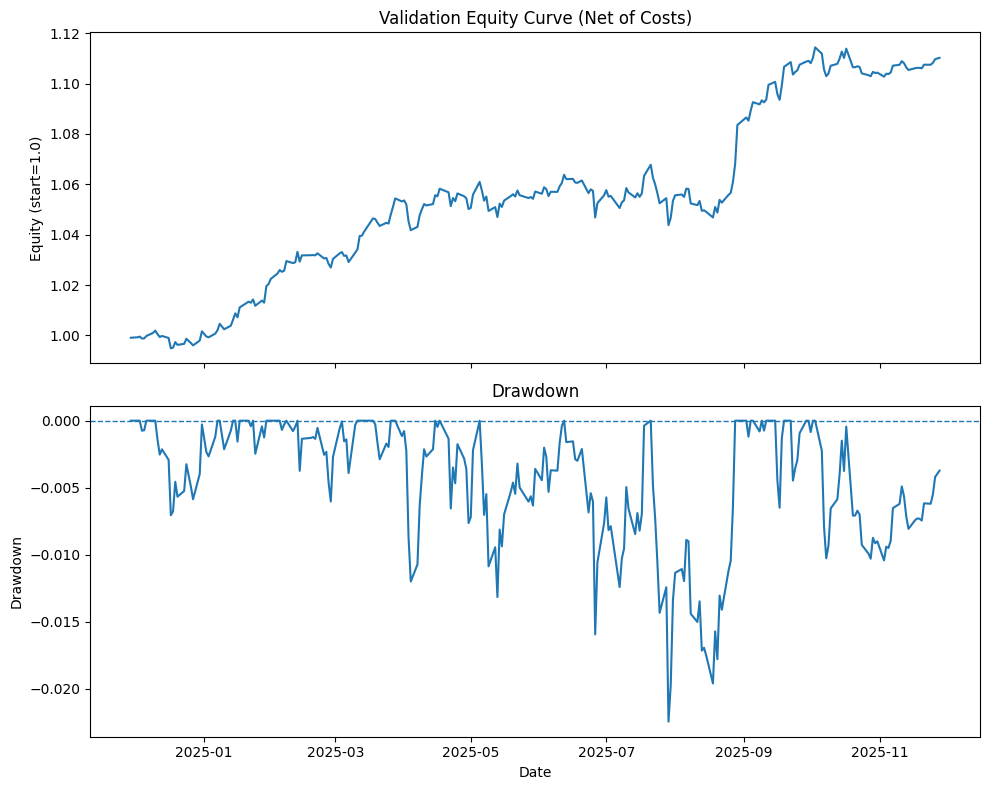

In [4]:
net_pnl = bt["net_pnl"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
cum_log_ret = net_pnl.cumsum()
equity = np.exp(cum_log_ret)

peak = np.maximum.accumulate(equity)
dd = (equity - peak) / peak  # drawdown

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

axes[0].plot(bt["date"], equity)
axes[0].set_title("Validation Equity Curve (Net of Costs)")
axes[0].set_ylabel("Equity (start=1.0)")

axes[1].plot(bt["date"], dd)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


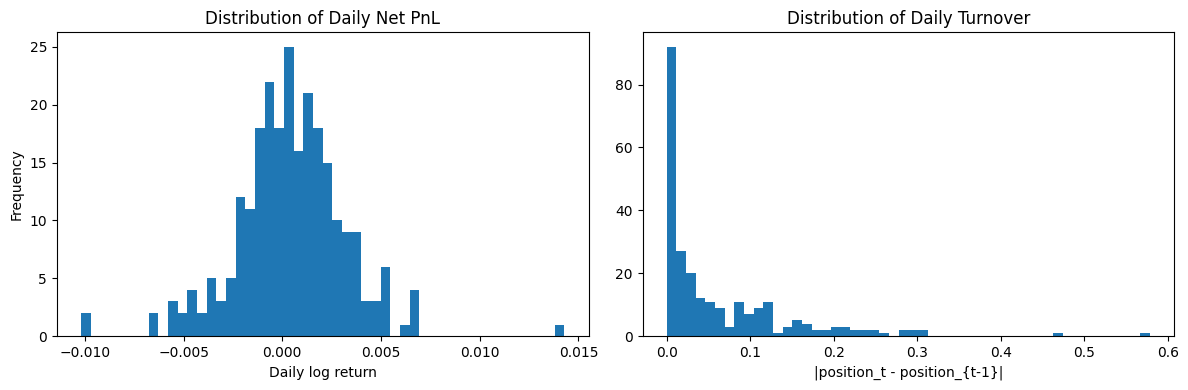

,turnover,trading_cost
count,250.000000,250.000000
mean,0.063250,0.000032
std,0.083740,0.000042
min,0.000000,0.000000
25%,0.008196,0.000004
50%,0.027554,0.000014
75%,0.096809,0.000048
max,0.578957,0.000289


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(net_pnl, bins=50)
axes[0].set_title("Distribution of Daily Net PnL")
axes[0].set_xlabel("Daily log return")
axes[0].set_ylabel("Frequency")

axes[1].hist(bt["turnover"], bins=50)
axes[1].set_title("Distribution of Daily Turnover")
axes[1].set_xlabel("|position_t - position_{t-1}|")

plt.tight_layout()
plt.show()

bt[["turnover", "trading_cost"]].describe()


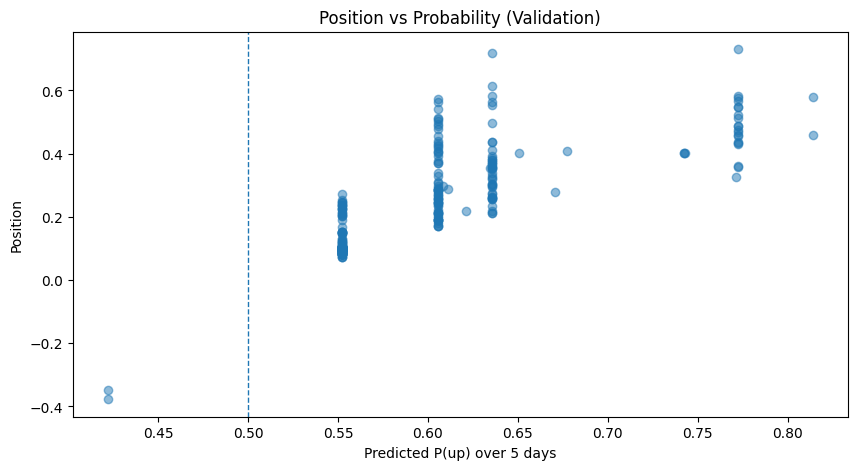

In [6]:
plt.scatter(bt["prob_up"], bt["position"], alpha=0.5)
plt.xlabel("Predicted P(up) over 5 days")
plt.ylabel("Position")
plt.title("Position vs Probability (Validation)")
plt.axvline(0.5, linestyle="--", linewidth=1)
plt.show()


In [7]:
pred = pd.read_csv(PRED_LOG_PATH, parse_dates=["date"])
pred.sort_values("date", inplace=True)
pred.tail(), pred.describe()


(        date  prob_up_5d    vol_20  position
 0 2025-11-28    0.552038  0.180484  0.099905,
                       date  prob_up_5d    vol_20  position
 count                    1    1.000000  1.000000  1.000000
 mean   2025-11-28 00:00:00    0.552038  0.180484  0.099905
 min    2025-11-28 00:00:00    0.552038  0.180484  0.099905
 25%    2025-11-28 00:00:00    0.552038  0.180484  0.099905
 50%    2025-11-28 00:00:00    0.552038  0.180484  0.099905
 75%    2025-11-28 00:00:00    0.552038  0.180484  0.099905
 max    2025-11-28 00:00:00    0.552038  0.180484  0.099905
 std                    NaN         NaN       NaN       NaN)

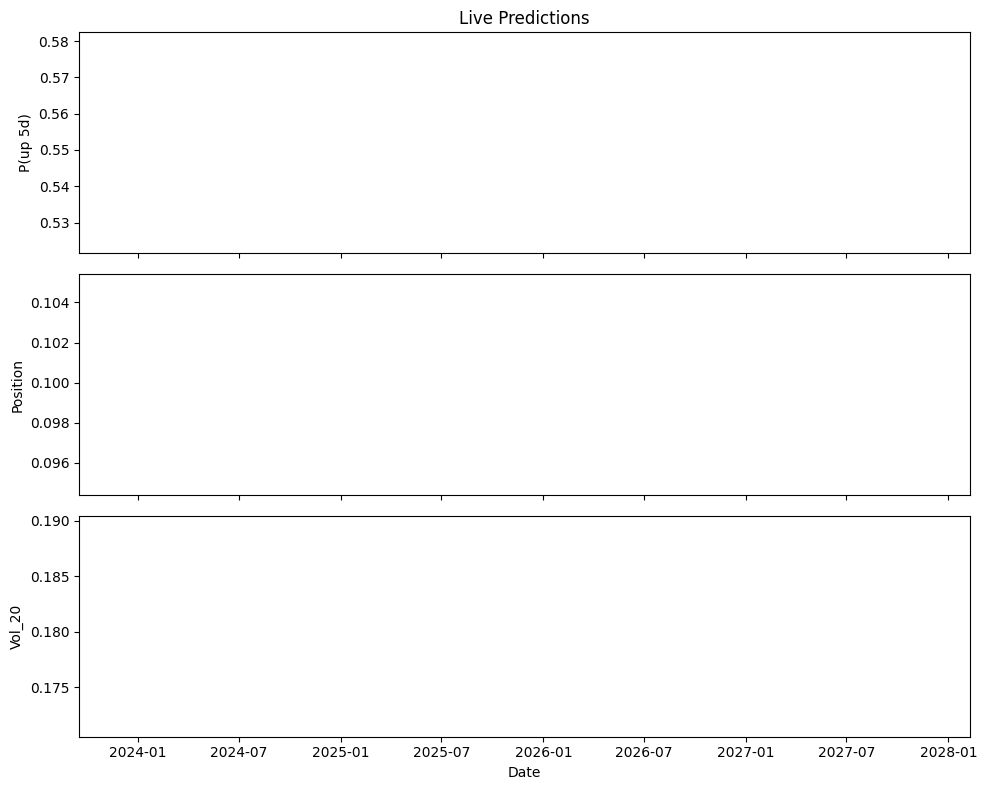

In [8]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

axes[0].plot(pred["date"], pred["prob_up_5d"])
axes[0].set_ylabel("P(up 5d)")
axes[0].set_title("Live Predictions")

axes[1].plot(pred["date"], pred["position"])
axes[1].set_ylabel("Position")

axes[2].plot(pred["date"], pred["vol_20"])
axes[2].set_ylabel("Vol_20")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


In [9]:
features = pd.read_csv(FEATURES_PATH, parse_dates=["date"]).sort_values("date")

live = pred.merge(
    features[["date", "target_ret_1d"]],
    on="date",
    how="inner",
)

live.head(), live.tail(), live.shape


(        date  prob_up_5d    vol_20  position  target_ret_1d
 0 2025-11-28    0.552038  0.180484  0.099905       0.004809,
         date  prob_up_5d    vol_20  position  target_ret_1d
 0 2025-11-28    0.552038  0.180484  0.099905       0.004809,
 (1, 5))

In [10]:
def compute_live_pnl(df: pd.DataFrame, cost_per_turnover: float = 0.0005):
    df = df.sort_values("date").copy()
    pos = df["position"].values
    ret = df["target_ret_1d"].values

    pos_prev = np.concatenate([[0.0], pos[:-1]])
    turnover = np.abs(pos - pos_prev)
    trading_costs = cost_per_turnover * turnover

    gross_pnl = pos * ret
    net_pnl = gross_pnl - trading_costs

    df["position_prev"] = pos_prev
    df["turnover"] = turnover
    df["trading_cost"] = trading_costs
    df["gross_pnl"] = gross_pnl
    df["net_pnl"] = net_pnl

    net_pnl_clean = df["net_pnl"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cum_log_ret = net_pnl_clean.cumsum()
    equity = np.exp(cum_log_ret)
    df["equity"] = equity

    stats = compute_stats_from_pnl(net_pnl_clean)
    return df, stats

live_bt, live_stats = compute_live_pnl(live)
live_stats


{'n_days': 1,
 'ann_return': np.float64(0.11460057420514858),
 'sharpe': np.float64(nan),
 'max_drawdown': np.float64(0.0)}

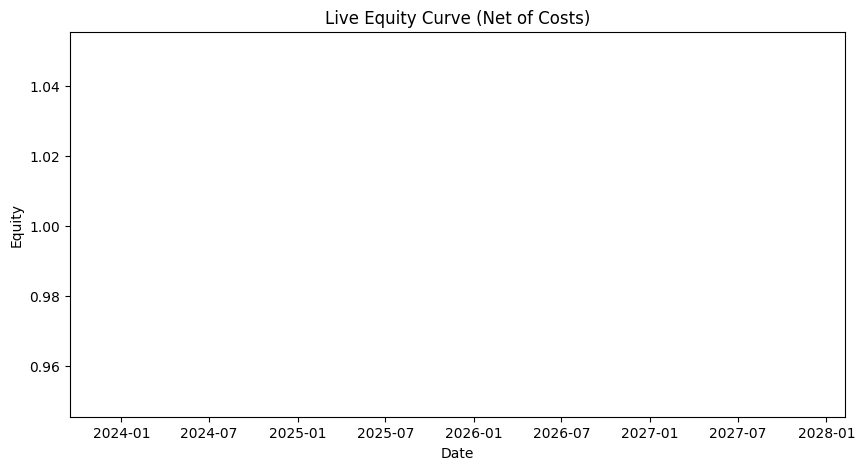

In [11]:
plt.plot(live_bt["date"], live_bt["equity"])
plt.title("Live Equity Curve (Net of Costs)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.show()


In [12]:
# Use the validation backtest dataframe as df_val
df_val = bt.copy()

# Build a live_df from your predictions log (pred)
#   - index by date
#   - rename prob_up_5d -> p_up so the function knows what to read
live_df = pred.copy()
live_df = live_df.set_index("date")
live_df = live_df.rename(columns={"prob_up_5d": "p_up"})

# Turnover stats from validation window
turnover_stats = bt[["turnover", "trading_cost"]].describe()

df_val.head(), live_df, turnover_stats

def quant_daily_summary(df_val=None, live_df=None, turnover_stats=None, portfolio_value: float = 100.0):
    print("\n" + "="*70)
    print("🧠  QUANT PM DAILY SUMMARY")
    print("="*70)

    # --- Safety checks ---
    if live_df is None or len(live_df) == 0:
        print("❌ No live predictions (live_df is empty or missing).")
        return

    # Take latest live prediction
    last = live_df.iloc[-1]
    date = live_df.index[-1].date() if isinstance(live_df.index[-1], pd.Timestamp) else live_df.index[-1]

    p_up = float(last.get("p_up", np.nan))
    pos  = float(last.get("position", np.nan))
    vol  = float(last.get("vol_20", np.nan))

    print(f"📅 Date evaluated: {date}")
    print(f"📈 Model probability GLD goes UP (next 5d): {p_up*100:.2f}%")
    print(f"🎯 Suggested position (−1 to +1): {pos:.2f}")
    print(f"⚠️ 20-day annualised volatility: {vol*100:.2f}%")

    # --- Conviction classification ---
    if p_up > 0.70:
        conviction = "HIGH UPSIDE BIAS"
    elif p_up > 0.60:
        conviction = "MODERATE UPSIDE BIAS"
    elif p_up > 0.52:
        conviction = "SLIGHT UPSIDE EDGE"
    elif p_up > 0.48:
        conviction = "NEUTRAL / NO EDGE"
    else:
        conviction = "DOWNSIDE BIAS"

    print(f"➡️ Conviction class: {conviction}")

    # --- Market interpretation ---
    print("\n--- MARKET INTERPRETATION ---")
    if vol > 0.20:
        print("• Market in HIGH volatility → signals less stable, position sizing should be cautious.")
    elif vol > 0.15:
        print("• Market in MODERATE volatility → environment broadly supportive of this strategy.")
    else:
        print("• Market in LOW volatility → trends tend to be cleaner, model edge often works best.")

    # --- Turnover & costs ---
    print("\n--- TURNOVER & COST PRESSURE ---")
    if turnover_stats is not None:
        avg_t = float(turnover_stats.loc["mean", "turnover"])
        med_t = float(turnover_stats.loc["50%", "turnover"])
        max_t = float(turnover_stats.loc["max", "turnover"])
        print(f"• Avg daily turnover: {avg_t:.3f}")
        print(f"• Median daily turnover: {med_t:.3f}")
        print(f"• Max daily turnover (worst flip): {max_t:.3f}")
        print("• Overall: strategy is very cheap to trade; trading costs are a small drag.")
    else:
        print("⚠️ turnover_stats not provided; cannot comment on cost pressure.")

    # --- Strategy health (validation backtest) ---
    print("\n--- STRATEGY HEALTH (Validation Window) ---")
    if df_val is not None and "equity" in df_val.columns:
        equity = df_val["equity"]
        peak = equity.cummax()
        dd_series = equity / peak - 1
        max_dd = dd_series.min()
        ann_ret = (equity.iloc[-1] - 1.0) * 100

        print(f"• Net return over validation period: {ann_ret:.2f}%")
        print(f"• Max drawdown: {max_dd*100:.2f}%")
        if ann_ret > 15 and max_dd > -5:
            print("• Pattern: strong compounding with shallow drawdowns → very robust behaviour.")
        else:
            print("• Pattern: more mixed; worth stress-testing further before committing real size.")
    else:
        print("⚠️ df_val missing or no 'equity' column; cannot summarise backtest health.")

    # --- ACTIONABLE TAKEAWAY (qualitative) ---
    print("\n--- ACTIONABLE TAKEAWAY (Qualitative) ---")
    if pos > 0.7:
        action_qual = "STRONG LONG"
        print("🔵 Model recommends a STRONG LONG position in gold.")
    elif pos > 0.3:
        action_qual = "MODERATE LONG"
        print("🟦 Model suggests a MODERATE LONG exposure.")
    elif pos > 0.05:
        action_qual = "SMALL LONG"
        print("🟩 Model suggests a SMALL LONG bias — use lighter size.")
    elif pos > -0.05:
        action_qual = "NEUTRAL"
        print("⚪ Model suggests staying NEUTRAL — no reliable edge today.")
    elif pos > -0.3:
        action_qual = "SMALL SHORT"
        print("🟧 Model suggests a SMALL SHORT bias.")
    else:
        action_qual = "STRONG SHORT"
        print("🔴 Model recommends a STRONG SHORT exposure in gold.")

    # --- HARD TRADE INSTRUCTION (for given portfolio) ---
    print("\n--- TRADE TICKET (Portfolio-Level) ---")
    notional = pos * portfolio_value  # £ exposure

    # Threshold: if very tiny, don't bother trading
    if abs(notional) < 0.50:
        print(f"• Portfolio value: £{portfolio_value:.2f}")
        print("• Implied trade size is less than £0.50 → NO TRADE recommended (too small to matter).")
    else:
        side = "BUY" if notional > 0 else "SELL"
        print(f"• Portfolio value: £{portfolio_value:.2f}")
        print(f"• Model action class: {action_qual}")
        print(f"• Implied notional: £{abs(notional):.2f}")
        print(f"➡️ TRADE INSTRUCTION: {side} £{abs(notional):.2f} of gold exposure.")
        print("   (e.g. via GLD ETF, XAUUSD CFD, or a physically-backed gold product.)")

    print("\n(End of daily quant summary)")
    print("="*70)


In [13]:
portfolio_value = 100.0  # you can change this later if you want

quant_daily_summary(
    df_val=df_val,
    live_df=live_df,
    turnover_stats=bt[["turnover", "trading_cost"]].describe(),
    portfolio_value=portfolio_value
)


🧠  QUANT PM DAILY SUMMARY
📅 Date evaluated: 2025-11-28
📈 Model probability GLD goes UP (next 5d): 55.20%
🎯 Suggested position (−1 to +1): 0.10
⚠️ 20-day annualised volatility: 18.05%
➡️ Conviction class: SLIGHT UPSIDE EDGE

--- MARKET INTERPRETATION ---
• Market in MODERATE volatility → environment broadly supportive of this strategy.

--- TURNOVER & COST PRESSURE ---
• Avg daily turnover: 0.063
• Median daily turnover: 0.028
• Max daily turnover (worst flip): 0.579
• Overall: strategy is very cheap to trade; trading costs are a small drag.

--- STRATEGY HEALTH (Validation Window) ---
• Net return over validation period: 11.02%
• Max drawdown: -2.24%
• Pattern: more mixed; worth stress-testing further before committing real size.

--- ACTIONABLE TAKEAWAY (Qualitative) ---
🟩 Model suggests a SMALL LONG bias — use lighter size.

--- TRADE TICKET (Portfolio-Level) ---
• Portfolio value: £100.00
• Model action class: SMALL LONG
• Implied notional: £9.99
➡️ TRADE INSTRUCTION: BUY £9.99 of 